# Best Method IQ Benchmark (Main Notebook)

This notebook runs the benchmark for the selected best IQ method (default: Metodo 3 IQ) using local SigMF files from the db path.

It measures and plots computational cost:
- File loading time
- IQ conversion time
- Welch PSD time
- Metric extraction time
- KDE time
- Total runtime and memory

In [10]:
print("H")

H


In [11]:
# If needed, install dependencies first:
# %pip install numpy scipy matplotlib psutil

import os
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import psutil
from scipy.signal import welch
from scipy.stats import gaussian_kde

print("Dependencies imported successfully.")

Dependencies imported successfully.


In [12]:
# ================================
# Configuration
# ================================
BEST_METHOD_NAME = "Metodo 3 IQ"

DB_ROOT = Path(r"D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\db")
DATASET_DIR = DB_ROOT / "DataBase-IQ-FM-88MHz-108MHz"

# Keep this small for quick profiling, increase for stronger statistics
N_FILES = 20 # change to 6 for quick test. 
N_PERSEG = 2048
KDE_GRID_POINTS = 256

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR}")

print(f"Best method selected: {BEST_METHOD_NAME}")
print(f"DB root traced: {DB_ROOT}")
print(f"Dataset dir: {DATASET_DIR}")

Best method selected: Metodo 3 IQ
DB root traced: D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\db
Dataset dir: D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\db\DataBase-IQ-FM-88MHz-108MHz


In [13]:
# ================================
# File selection (best available local files)
# Strategy: pick largest SigMF captures with matching meta/data
# ================================
data_files = sorted(DATASET_DIR.glob("*.sigmf-data"))

pairs = []
for d in data_files:
    m = d.with_suffix("").with_suffix(".sigmf-meta")
    if m.exists():
        pairs.append((d, m, d.stat().st_size))

if not pairs:
    raise RuntimeError("No valid .sigmf-data/.sigmf-meta pairs found.")

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:N_FILES]

print(f"Selected {len(pairs)} files for benchmark:")
for i, (d, m, sz) in enumerate(pairs, start=1):
    print(f"{i:02d}. {d.name} | {sz/1024/1024:.2f} MB")

Selected 6 files for benchmark:
01. 01_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
02. 02_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
03. 03_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
04. 04_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
05. 05_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB
06. 06_98MHz_20Ms_L16dB_G16dB_NoAmp.sigmf-data | 50.00 MB


In [14]:
# ================================
# Benchmark helpers
# ================================
def load_sigmf_pair(data_path: Path, meta_path: Path):
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    with open(data_path, "rb") as f:
        raw_int8 = np.frombuffer(f.read(), dtype=np.int8)

    fs = int(meta["global"]["core:sample_rate"])
    fc = int(meta["captures"][0]["core:frequency"])

    return raw_int8, fs, fc


def to_complex_iq(raw_int8: np.ndarray):
    if raw_int8.size % 2 != 0:
        raw_int8 = raw_int8[:-1]
    i = raw_int8[0::2].astype(np.float32)
    q = raw_int8[1::2].astype(np.float32)
    return i + 1j * q


def compute_psd_metrics(iq_complex: np.ndarray, fs: int, nperseg: int = 2048):
    iq_centered = iq_complex - np.mean(iq_complex)
    f, pxx = welch(iq_centered, fs=fs, nperseg=min(nperseg, len(iq_centered)), return_onesided=False)

    f_shifted = np.fft.fftshift(f)
    pxx_db = 10.0 * np.log10(np.fft.fftshift(pxx) + 1e-12)

    noise_floor_dbm = float(np.mean(pxx_db))
    f_center = 0.5 * (f_shifted[0] + f_shifted[-1])
    idx_center = int(np.argmin(np.abs(f_shifted - f_center)))
    p_center_dbm = float(pxx_db[idx_center])
    snr_center_db = float(p_center_dbm - noise_floor_dbm)

    return f_shifted, pxx_db, noise_floor_dbm, p_center_dbm, snr_center_db


def safe_kde(samples, grid_points=256):
    x = np.asarray(samples, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return None, None

    xmin, xmax = np.min(x), np.max(x)
    xr = xmax - xmin if xmax > xmin else 1.0
    margin = 0.2 * xr
    grid = np.linspace(xmin - margin, xmax + margin, grid_points)

    kde = gaussian_kde(x, bw_method="scott")
    y = kde(grid)
    return grid, y

In [15]:
# ================================
# Run benchmark
# ================================
proc = psutil.Process()
rss_start_mb = proc.memory_info().rss / (1024 * 1024)
t0_total = time.perf_counter()

timing = {
    "load_ms": [],
    "convert_ms": [],
    "welch_ms": [],
    "metric_ms": [],
}

noise_vals = []
center_vals = []
snr_vals = []
file_labels = []
file_total_ms = []

for data_path, meta_path, _ in pairs:
    t_file = time.perf_counter()

    t0 = time.perf_counter()
    raw_iq, fs, fc = load_sigmf_pair(data_path, meta_path)
    timing["load_ms"].append((time.perf_counter() - t0) * 1000.0)

    t0 = time.perf_counter()
    iq = to_complex_iq(raw_iq)
    timing["convert_ms"].append((time.perf_counter() - t0) * 1000.0)

    t0 = time.perf_counter()
    f, pxx_db, nf, pc, snr = compute_psd_metrics(iq, fs, nperseg=N_PERSEG)
    welch_elapsed = (time.perf_counter() - t0) * 1000.0
    timing["welch_ms"].append(welch_elapsed)

    t0 = time.perf_counter()
    _ = (nf, pc, snr)
    timing["metric_ms"].append((time.perf_counter() - t0) * 1000.0)

    noise_vals.append(nf)
    center_vals.append(pc)
    snr_vals.append(snr)

    file_labels.append(data_path.stem.split("_")[0])
    file_total_ms.append((time.perf_counter() - t_file) * 1000.0)

t0 = time.perf_counter()
kde_noise = safe_kde(noise_vals, grid_points=KDE_GRID_POINTS)
kde_center = safe_kde(center_vals, grid_points=KDE_GRID_POINTS)
kde_snr = safe_kde(snr_vals, grid_points=KDE_GRID_POINTS)
kde_ms = (time.perf_counter() - t0) * 1000.0

total_ms = (time.perf_counter() - t0_total) * 1000.0
rss_end_mb = proc.memory_info().rss / (1024 * 1024)

summary = {
    "best_method": BEST_METHOD_NAME,
    "files": len(pairs),
    "samples_total": int(sum(len(to_complex_iq(load_sigmf_pair(d, m)[0])) for d, m, _ in pairs)),
    "load_ms_total": float(np.sum(timing["load_ms"])),
    "convert_ms_total": float(np.sum(timing["convert_ms"])),
    "welch_ms_total": float(np.sum(timing["welch_ms"])),
    "metric_ms_total": float(np.sum(timing["metric_ms"])),
    "kde_ms_total": float(kde_ms),
    "total_ms": float(total_ms),
    "rss_start_mb": float(rss_start_mb),
    "rss_end_mb": float(rss_end_mb),
    "rss_delta_mb": float(rss_end_mb - rss_start_mb),
    "snr_mean_db": float(np.mean(snr_vals)),
    "snr_std_db": float(np.std(snr_vals, ddof=1)) if len(snr_vals) > 1 else 0.0,
    "noise_mean_dbm": float(np.mean(noise_vals)),
    "center_mean_dbm": float(np.mean(center_vals)),
}

print("=" * 88)
print("BEST METHOD BENCHMARK SUMMARY")
print("=" * 88)
for k, v in summary.items():
    print(f"{k:20s}: {v}")

BEST METHOD BENCHMARK SUMMARY
best_method         : Metodo 3 IQ
files               : 6
samples_total       : 157286400
load_ms_total       : 875.2327999100089
convert_ms_total    : 2481.1758000287227
welch_ms_total      : 36182.09349992685
metric_ms_total     : 0.01409999094903469
kde_ms_total        : 4.997199983336031
total_ms            : 39544.82300003292
rss_start_mb        : 384.296875
rss_end_mb          : 384.26171875
rss_delta_mb        : -0.03515625
snr_mean_db         : 3.004906972249349
snr_std_db          : 0.05224979900355979
noise_mean_dbm      : -74.48205693562825
center_mean_dbm     : -71.4771499633789


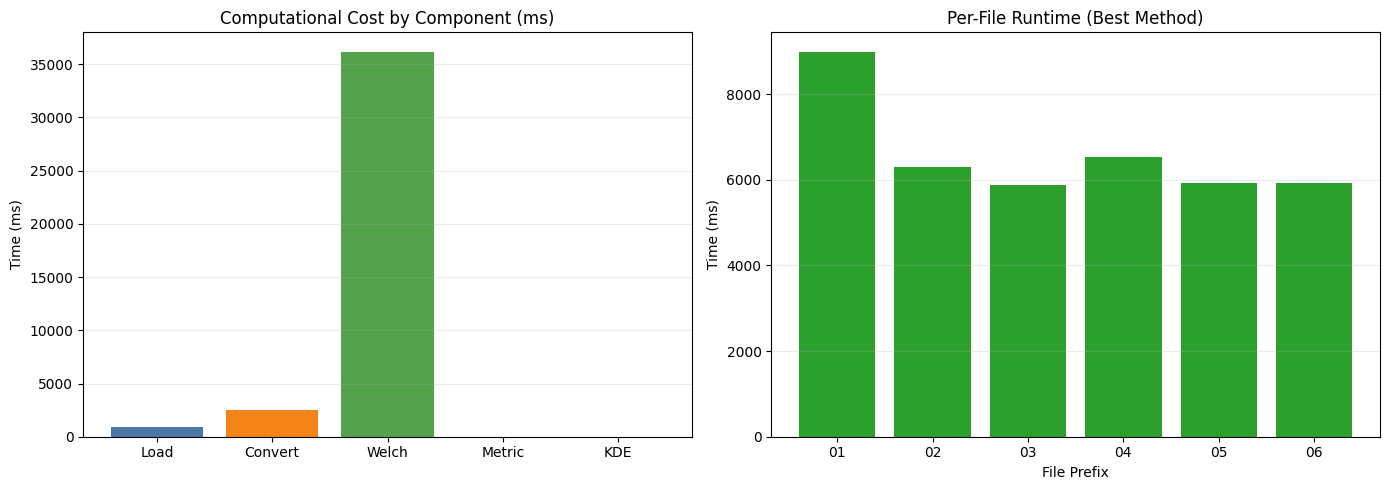

In [16]:
# ================================
# Plot computational cost
# ================================
cost_labels = ["Load", "Convert", "Welch", "Metric", "KDE"]
cost_values = [
    summary["load_ms_total"],
    summary["convert_ms_total"],
    summary["welch_ms_total"],
    summary["metric_ms_total"],
    summary["kde_ms_total"],
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cost_labels, cost_values, color=["#4c78a8", "#f58518", "#54a24b", "#e45756", "#72b7b2"])
axes[0].set_title("Computational Cost by Component (ms)")
axes[0].set_ylabel("Time (ms)")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(file_labels, file_total_ms, color="#2ca02c")
axes[1].set_title("Per-File Runtime (Best Method)")
axes[1].set_xlabel("File Prefix")
axes[1].set_ylabel("Time (ms)")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

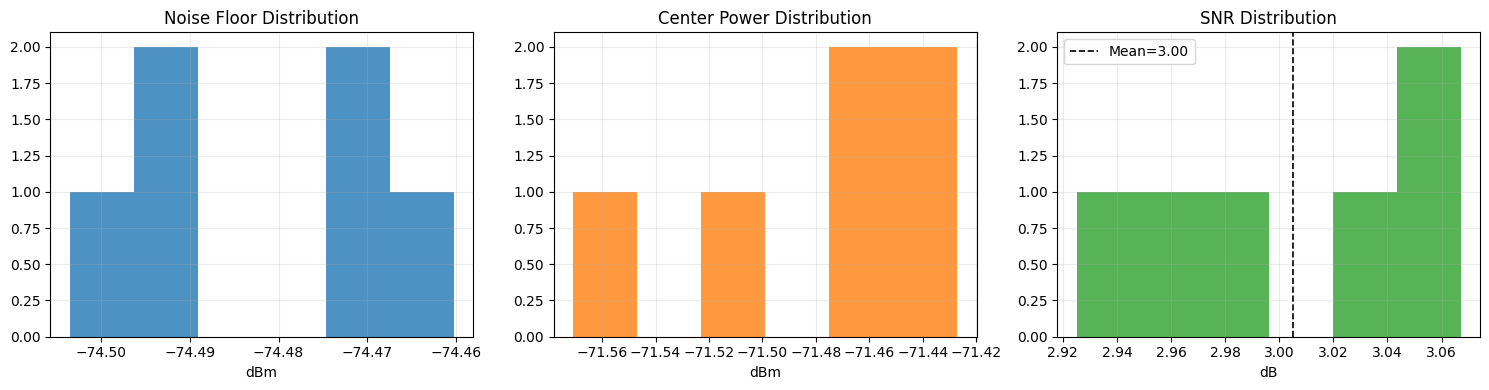

In [17]:
# ================================
# Plot KPI distributions for best method
# ================================
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(noise_vals, bins=min(10, max(3, len(noise_vals))), color="#1f77b4", alpha=0.8)
ax[0].set_title("Noise Floor Distribution")
ax[0].set_xlabel("dBm")
ax[0].grid(alpha=0.25)

ax[1].hist(center_vals, bins=min(10, max(3, len(center_vals))), color="#ff7f0e", alpha=0.8)
ax[1].set_title("Center Power Distribution")
ax[1].set_xlabel("dBm")
ax[1].grid(alpha=0.25)

ax[2].hist(snr_vals, bins=min(10, max(3, len(snr_vals))), color="#2ca02c", alpha=0.8)
ax[2].axvline(np.mean(snr_vals), linestyle="--", color="black", linewidth=1.2, label=f"Mean={np.mean(snr_vals):.2f}")
ax[2].set_title("SNR Distribution")
ax[2].set_xlabel("dB")
ax[2].grid(alpha=0.25)
ax[2].legend()

plt.tight_layout()
plt.show()

In [18]:
# Save benchmark output for C comparison
out_path = Path("best_method_python_metrics.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Saved metrics to: {out_path.resolve()}")

Saved metrics to: D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\spectrumAnalysis\narrowband\preprocess\src\test\prslIQ\best_method_python_metrics.json


In [19]:
# Derived KPIs that matter for optimization decisions
samples_total = summary["samples_total"]
total_s = summary["total_ms"] / 1000.0

throughput_sps = samples_total / total_s if total_s > 0 else 0.0
avg_file_ms = summary["total_ms"] / summary["files"] if summary["files"] > 0 else 0.0

parts = {
    "Load": summary["load_ms_total"],
    "Convert": summary["convert_ms_total"],
    "Welch": summary["welch_ms_total"],
    "Metric": summary["metric_ms_total"],
    "KDE": summary["kde_ms_total"],
}

print("=" * 88)
print("CRITICAL PERFORMANCE KPIs")
print("=" * 88)
print(f"Best method                 : {summary['best_method']}")
print(f"Files processed             : {summary['files']}")
print(f"Total samples               : {samples_total:,}")
print(f"Total runtime               : {summary['total_ms']:.2f} ms")
print(f"Avg runtime per file        : {avg_file_ms:.2f} ms")
print(f"Throughput                  : {throughput_sps:,.2f} samples/s")
print(f"SNR mean +- std             : {summary['snr_mean_db']:.4f} +- {summary['snr_std_db']:.4f} dB")
print(f"Noise floor mean            : {summary['noise_mean_dbm']:.4f} dBm")
print(f"Center power mean           : {summary['center_mean_dbm']:.4f} dBm")
print(f"RSS delta                   : {summary['rss_delta_mb']:.4f} MB")

print("\nComponent share of measured total:")
for name, val in parts.items():
    pct = 100.0 * val / summary["total_ms"] if summary["total_ms"] > 0 else 0.0
    print(f"- {name:7s}: {val:10.3f} ms ({pct:6.2f}%)")

print("\nOptimization priority:")
ranked = sorted(parts.items(), key=lambda x: x[1], reverse=True)
for i, (name, val) in enumerate(ranked, start=1):
    print(f"{i}. {name} ({val:.3f} ms)")

CRITICAL PERFORMANCE KPIs
Best method                 : Metodo 3 IQ
Files processed             : 6
Total samples               : 157,286,400
Total runtime               : 39544.82 ms
Avg runtime per file        : 6590.80 ms
Throughput                  : 3,977,420.76 samples/s
SNR mean +- std             : 3.0049 +- 0.0522 dB
Noise floor mean            : -74.4821 dBm
Center power mean           : -71.4771 dBm
RSS delta                   : -0.0352 MB

Component share of measured total:
- Load   :    875.233 ms (  2.21%)
- Convert:   2481.176 ms (  6.27%)
- Welch  :  36182.093 ms ( 91.50%)
- Metric :      0.014 ms (  0.00%)
- KDE    :      4.997 ms (  0.01%)

Optimization priority:
1. Welch (36182.093 ms)
2. Convert (2481.176 ms)
3. Load (875.233 ms)
4. KDE (4.997 ms)
5. Metric (0.014 ms)


## Acquisition Health Framework (HackRF/RPi-Oriented)

This section adds missing operational metrics on top of the existing benchmark:
- Throughput efficiency and drop-rate approximation
- Chunk jitter and timing stability
- IQ quality indicators (DC offset, gain imbalance, quadrature error, clipping)
- Memory snapshots (current/peak RAM)
- CPU utilization estimate
- Composite health score and status

Notes:
- Hardware register fidelity metrics require a live SDR object and are optional in this offline dataset workflow.
- This framework is designed to be reused in live acquisition loops later.

ACQUISITION HEALTH REPORT
Status: OPTIMAL | Score: 0.920
Throughput efficiency: 100.00%
Drop rate: 0.0000%
Chunk jitter: 1099.538 ms
DC offset: 0.000000
IQ gain imbalance: 0.0128 dB
IQ quadrature error: 0.001442
Clipping rate: 0.000000%
Dynamic range: 0.000 dB
RAM current: 250.005 MB
RAM peak (tracemalloc): 1050.005 MB
RAM process %: 1.772%
Estimated CPU % of run: 12.56%


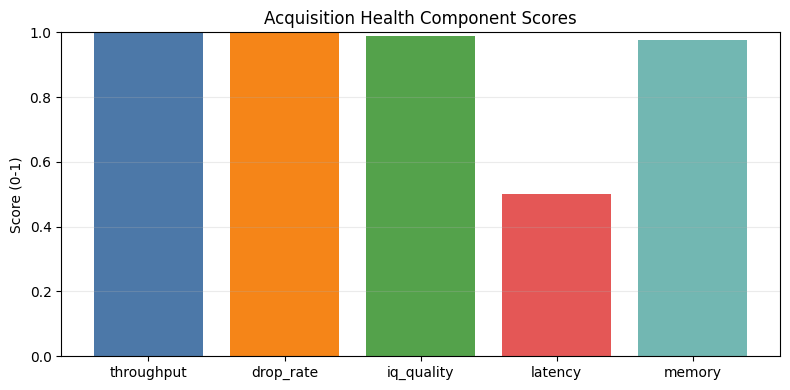

Saved: acquisition_health_report.json


In [20]:
import gc
import tracemalloc

# Optional live-SDR check helper (use when SoapySDR/HackRF stream is active)
def verify_hardware_config(sdr, expected_freq, expected_sr, expected_lna):
    actual_freq = sdr.getFrequency(SoapySDR.SOAPY_SDR_RX, 0)
    actual_sr = sdr.getSampleRate(SoapySDR.SOAPY_SDR_RX, 0)
    actual_lna = sdr.getGain(SoapySDR.SOAPY_SDR_RX, 0, "LNA")
    return {
        "freq_error_hz": abs(actual_freq - expected_freq),
        "sr_error_hz": abs(actual_sr - expected_sr),
        "lna_error_db": abs(actual_lna - expected_lna),
        "config_valid": (
            abs(actual_freq - expected_freq) < 100
            and abs(actual_sr - expected_sr) < 100
            and abs(actual_lna - expected_lna) < 1
        ),
    }


class StreamMetrics:
    def __init__(self, expected_sample_rate, chunk_samples):
        self.expected_sr = expected_sample_rate
        self.chunk_samples = chunk_samples
        self.chunk_times = []
        self.samples_received = []
        self.overrun_count = 0

    def record_chunk(self, samples_read, chunk_duration_s):
        self.samples_received.append(samples_read)
        self.chunk_times.append(chunk_duration_s)

    def compute_report(self):
        total_expected = len(self.chunk_times) * self.chunk_samples
        total_received = sum(self.samples_received)
        eff = (total_received / total_expected) if total_expected > 0 else 0.0
        return {
            "throughput_efficiency": eff,
            "drop_rate_pct": max(0.0, (1.0 - eff) * 100.0),
            "avg_chunk_time_s": float(np.mean(self.chunk_times)) if self.chunk_times else 0.0,
            "chunk_jitter_ms": float(np.std(self.chunk_times) * 1000.0) if self.chunk_times else 0.0,
            "overruns": self.overrun_count,
        }


def iq_capture_quality(raw_i8: np.ndarray, normalized_iq: np.ndarray):
    i = normalized_iq.real
    q = normalized_iq.imag

    dc_offset = float(np.abs(np.mean(normalized_iq)))

    p_i = float(np.var(i))
    p_q = float(np.var(q))
    gain_imb_db = 10.0 * np.log10((p_i + 1e-20) / (p_q + 1e-20))

    iq_corr = float(np.corrcoef(i, q)[0, 1])

    clip_rate = float(np.sum(np.abs(raw_i8) >= 127) / len(raw_i8)) if len(raw_i8) else 0.0

    signal_rms = float(np.sqrt(np.mean(np.abs(normalized_iq) ** 2)))
    noise_rms = float(np.std(normalized_iq - np.mean(normalized_iq)))
    dyn_range_db = 20.0 * np.log10(signal_rms / (noise_rms + 1e-20))

    return {
        "dc_offset": dc_offset,
        "gain_imbalance_db": abs(gain_imb_db),
        "quadrature_error": abs(iq_corr),
        "clipping_rate_pct": clip_rate * 100.0,
        "dynamic_range_db": dyn_range_db,
    }


class BufferMetrics:
    def __init__(self):
        tracemalloc.start()
        self.process = psutil.Process()

    def snapshot(self):
        current, peak = tracemalloc.get_traced_memory()
        return {
            "ram_current_mb": current / 1024**2,
            "ram_peak_mb": peak / 1024**2,
            "ram_percent": self.process.memory_percent(),
            "gc_count": gc.get_count(),
        }


def compute_acquisition_health(stream_metrics, iq_metrics, buffer_metrics, chunk_duration_s):
    weights = {
        "throughput": 0.30,
        "drop_rate": 0.25,
        "iq_quality": 0.20,
        "latency": 0.15,
        "memory": 0.10,
    }

    scores = {
        "throughput": min(1.0, stream_metrics["throughput_efficiency"]),
        "drop_rate": max(0.0, 1.0 - stream_metrics["drop_rate_pct"] / 1.0),
        "iq_quality": max(
            0.0,
            1.0
            - (
                iq_metrics["gain_imbalance_db"] / 2.0
                + iq_metrics["quadrature_error"] / 0.05
                + iq_metrics["dc_offset"] / 0.02
            )
            / 3.0,
        ),
        "latency": max(0.0, 1.0 - (buffer_metrics.get("avg_latency_s", 0.0) / (chunk_duration_s * 2.0))),
        "memory": max(0.0, 1.0 - buffer_metrics["ram_percent"] / 80.0),
    }

    health = sum(weights[k] * scores[k] for k in weights)

    if health > 0.9:
        status = "OPTIMAL"
    elif health > 0.7:
        status = "GOOD"
    elif health > 0.4:
        status = "DEGRADED"
    else:
        status = "CRITICAL"

    return {
        "health_score": health,
        "component_scores": scores,
        "status": status,
    }


# Apply framework to current benchmark artifacts already computed above
buffer_mon = BufferMetrics()
proc_health = psutil.Process()
cpu_before = proc_health.cpu_times()

chunk_samples = int(np.mean([len(to_complex_iq(load_sigmf_pair(d, m)[0])) for d, m, _ in pairs]))
expected_sr = fs if "fs" in globals() else 20_000_000
stream_mon = StreamMetrics(expected_sr, chunk_samples)

for ms in file_total_ms:
    stream_mon.record_chunk(chunk_samples, ms / 1000.0)

stream_report = stream_mon.compute_report()

# Use one representative file to evaluate IQ quality metrics
raw0, fs0, _fc0 = load_sigmf_pair(pairs[0][0], pairs[0][1])
iq0 = to_complex_iq(raw0)
iq0 = iq0 - np.mean(iq0)
rms0 = np.sqrt(np.mean(np.abs(iq0) ** 2))
if rms0 > 1e-12:
    iq0 = iq0 / rms0
iq_report = iq_capture_quality(raw0, iq0)

buf_snap = buffer_mon.snapshot()
buf_snap["avg_latency_s"] = stream_report["avg_chunk_time_s"]

health = compute_acquisition_health(
    stream_report,
    iq_report,
    buf_snap,
    stream_report["avg_chunk_time_s"] if stream_report["avg_chunk_time_s"] > 0 else 1e-3,
)

cpu_after = proc_health.cpu_times()
cpu_time_delta_s = (cpu_after.user + cpu_after.system) - (cpu_before.user + cpu_before.system)
wall_s = summary["total_ms"] / 1000.0 if "summary" in globals() else 0.0
cpu_percent_est = (100.0 * cpu_time_delta_s / wall_s) if wall_s > 0 else 0.0

print("=" * 90)
print("ACQUISITION HEALTH REPORT")
print("=" * 90)
print(f"Status: {health['status']} | Score: {health['health_score']:.3f}")
print(f"Throughput efficiency: {stream_report['throughput_efficiency']*100:.2f}%")
print(f"Drop rate: {stream_report['drop_rate_pct']:.4f}%")
print(f"Chunk jitter: {stream_report['chunk_jitter_ms']:.3f} ms")
print(f"DC offset: {iq_report['dc_offset']:.6f}")
print(f"IQ gain imbalance: {iq_report['gain_imbalance_db']:.4f} dB")
print(f"IQ quadrature error: {iq_report['quadrature_error']:.6f}")
print(f"Clipping rate: {iq_report['clipping_rate_pct']:.6f}%")
print(f"Dynamic range: {iq_report['dynamic_range_db']:.3f} dB")
print(f"RAM current: {buf_snap['ram_current_mb']:.3f} MB")
print(f"RAM peak (tracemalloc): {buf_snap['ram_peak_mb']:.3f} MB")
print(f"RAM process %: {buf_snap['ram_percent']:.3f}%")
print(f"Estimated CPU % of run: {cpu_percent_est:.2f}%")

# Visualize component scores
labels = list(health["component_scores"].keys())
vals = [health["component_scores"][k] for k in labels]

plt.figure(figsize=(8, 4))
plt.bar(labels, vals, color=["#4c78a8", "#f58518", "#54a24b", "#e45756", "#72b7b2"])
plt.ylim(0, 1)
plt.title("Acquisition Health Component Scores")
plt.ylabel("Score (0-1)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

acq_health_report = {
    "stream": stream_report,
    "iq": iq_report,
    "buffer": buf_snap,
    "health": health,
    "cpu_percent_est": cpu_percent_est,
}

with open("acquisition_health_report.json", "w", encoding="utf-8") as f:
    json.dump(acq_health_report, f, indent=2)

print("Saved: acquisition_health_report.json")

## C Executable Metrics (Loaded from qa_after_v2.json)

This cell reads the C benchmark output and visualizes the most relevant computational metrics:
- Total runtime and stage costs
- CPU usage percent
- RAM usage percent and peak RSS
- Throughput efficiency and drop rate
- Jitter and latency ratio

C BENCHMARK METRICS
source_json            : src\c\qa_after_v3.json
total_ms              : 4.7209
load_ms               : 0.2649
convert_ms            : 0.0896
preprocess_ms         : 0.3055
welch_ms              : 2.6786
metric_ms             : 0.0075
cpu_percent           : 105.912008
ram_percent           : 87.0
rss_peak_mb           : 4.144531
throughput_sps        : 13882098.75488
throughput_efficiency : 1.0
drop_rate_pct         : 0.0
avg_file_ms           : 1.85675
file_jitter_ms        : 0.08959
latency_ratio         : 1.13327
snr_mean_db           : 12.080563
snr_std_db            : 0.485607
noise_mean_dbm        : -74.210926
center_mean_dbm       : -62.130363


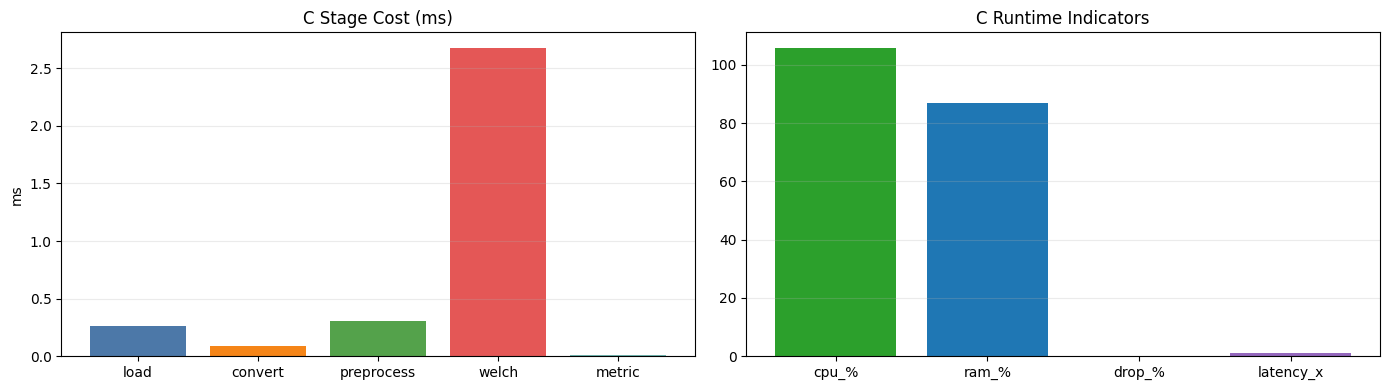

In [22]:
c_candidates = [
    Path("src/c/qa_after_v3.json"),
    Path("src/c/qa_after_v2.json"),
    Path("src/c/qa_after.json"),
]

c_json = next((p for p in c_candidates if p.exists()), None)

if c_json is not None:
    with open(c_json, "r", encoding="utf-8") as f:
        c_metrics = json.load(f)

    print("=" * 90)
    print("C BENCHMARK METRICS")
    print("=" * 90)
    print(f"source_json            : {c_json}")
    keys_to_show = [
        "total_ms", "load_ms", "convert_ms", "preprocess_ms", "welch_ms", "metric_ms",
        "cpu_percent", "ram_percent", "rss_peak_mb",
        "throughput_sps", "throughput_efficiency", "drop_rate_pct",
        "avg_file_ms", "file_jitter_ms", "latency_ratio",
        "snr_mean_db", "snr_std_db", "noise_mean_dbm", "center_mean_dbm"
    ]
    for k in keys_to_show:
        if k in c_metrics:
            print(f"{k:22s}: {c_metrics[k]}")

    # Cost bars
    stage_labels = ["load", "convert", "preprocess", "welch", "metric"]
    stage_values = [c_metrics.get(f"{k}_ms", 0.0) for k in stage_labels]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(stage_labels, stage_values, color=["#4c78a8", "#f58518", "#54a24b", "#e45756", "#72b7b2"])

    axes[0].set_title("C Stage Cost (ms)")
    axes[0].set_ylabel("ms")
    axes[0].grid(axis="y", alpha=0.25)

    # System/runtime indicators
    ind_labels = ["cpu_%", "ram_%", "drop_%", "latency_x"]
    ind_values = [
        c_metrics.get("cpu_percent", 0.0),
        c_metrics.get("ram_percent", 0.0),
        c_metrics.get("drop_rate_pct", 0.0),
        c_metrics.get("latency_ratio", 0.0),
    ]
    axes[1].bar(ind_labels, ind_values, color=["#2ca02c", "#1f77b4", "#d62728", "#9467bd"])

    axes[1].set_title("C Runtime Indicators")
    axes[1].grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print("C metrics JSON not found. Run iq_method3_bench.exe with --json-out qa_after_v3.json first.")